<a href="https://colab.research.google.com/github/cristiangaymartin/tfm-estados-mercado/blob/main/notebooks/01_ingesta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install yfinance --quiet

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ticker = "^GSPC"
sp500 = yf.download(ticker, start="1990-01-01", auto_adjust=True)
print(sp500.shape)   # (nº de filas, nº de columnas)
sp500.head()          # primeras filas para inspeccionar

[*********************100%***********************]  1 of 1 completed

(9210, 5)


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000


In [4]:
print("Rango de fechas:", sp500.index.min(), "→", sp500.index.max())
print("Valores ausentes por columna:")
print(sp500.isna().sum())

Rango de fechas: 1990-01-02 00:00:00 → 2026-07-29 00:00:00
Valores ausentes por columna:
Price   Ticker
Close   ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Open    ^GSPC     0
Volume  ^GSPC     0
dtype: int64


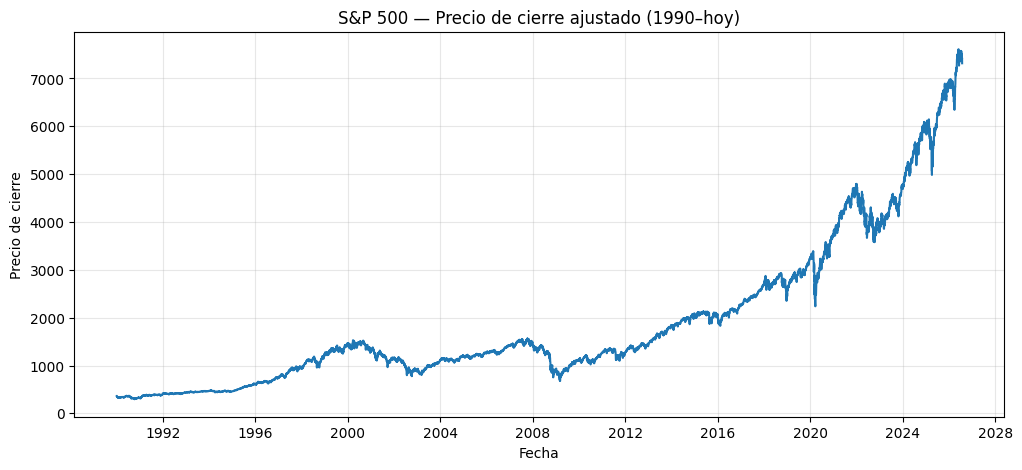

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(sp500.index, sp500["Close"])
plt.title("S&P 500 — Precio de cierre ajustado (1990–hoy)")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Antes: columnas con dos niveles (Price + Ticker)
print("Columnas antes:", sp500.columns.tolist())

# Eliminamos el segundo nivel (el del ticker), que es redundante con un solo activo
sp500.columns = sp500.columns.droplevel(1)

# Después: columnas simples
print("Columnas después:", sp500.columns.tolist())
sp500.head()

Columnas antes: [('Close', '^GSPC'), ('High', '^GSPC'), ('Low', '^GSPC'), ('Open', '^GSPC'), ('Volume', '^GSPC')]
Columnas después: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
Date,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000


In [8]:
# Rendimiento simple: cambio porcentual diario
sp500["ret_simple"] = sp500["Close"].pct_change()

# Rendimiento logarítmico: log del cociente de precios consecutivos
sp500["ret_log"] = np.log(sp500["Close"] / sp500["Close"].shift(1))

# Miramos las primeras filas para entender qué ha pasado
sp500[["Close", "ret_simple", "ret_log"]].head()

Price,Close,ret_simple,ret_log
Date,,,
1990-01-02,359.690002,NaN,NaN
1990-01-03,358.760010,-0.002586,-0.002589
1990-01-04,355.670013,-0.008613,-0.008650
1990-01-05,352.200012,-0.009756,-0.009804
1990-01-08,353.790009,0.004514,0.004504


In [10]:
# Volatilidad = desviación típica de los log-rendimientos en una ventana de 21 días (~1 mes bursátil)
sp500["vol_21d"] = sp500["ret_log"].rolling(window=21).std()

# Visualizamos las tres piezas juntas
sp500[["ret_log", "vol_21d"]].tail(10)

Price,ret_log,vol_21d
Date,,
2026-07-16,-0.005114,0.007096
2026-07-17,-0.010150,0.007333
2026-07-20,-0.001934,0.006825
2026-07-21,0.008817,0.006684
2026-07-22,-0.001365,0.006637
2026-07-23,-0.012163,0.006398
2026-07-24,0.000497,0.006392
2026-07-27,0.000162,0.006391
2026-07-28,0.002102,0.006399


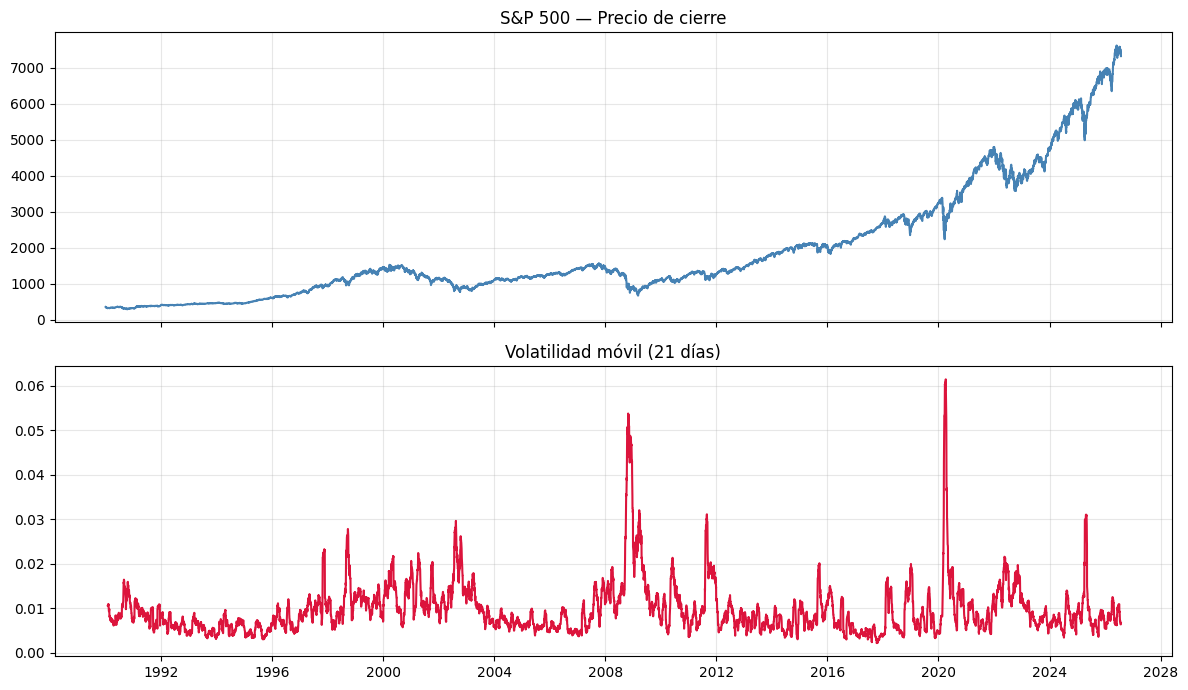

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(sp500.index, sp500["Close"], color="steelblue")
ax1.set_title("S&P 500 — Precio de cierre")
ax1.grid(True, alpha=0.3)

ax2.plot(sp500.index, sp500["vol_21d"], color="crimson")
ax2.set_title("Volatilidad móvil (21 días)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
sp500[["ret_log", "vol_21d"]].describe()

Price,ret_log,vol_21d
count,9209.000000,9189.000000
mean,0.000327,0.009702
std,0.011347,0.006019
min,-0.127652,0.002185
25%,-0.004426,0.006095
50%,0.000598,0.008244
75%,0.005703,0.011528
max,0.109572,0.061454


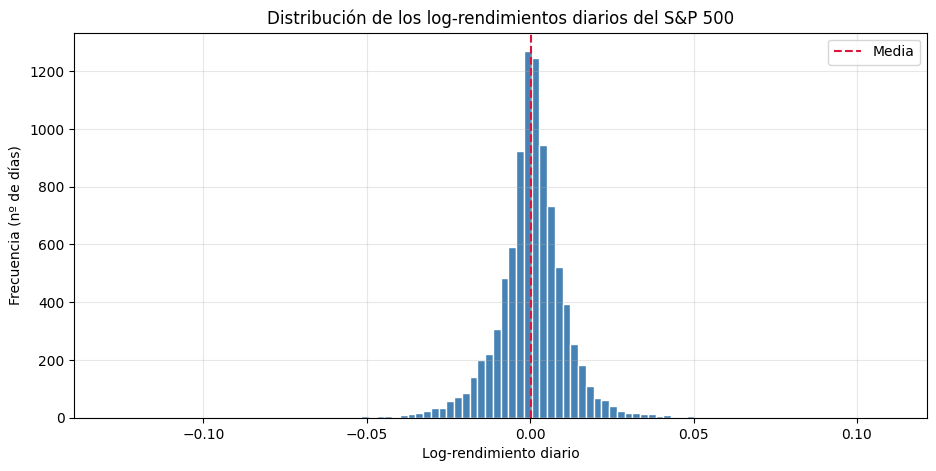

In [13]:
plt.figure(figsize=(11, 5))
plt.hist(sp500["ret_log"].dropna(), bins=100, color="steelblue", edgecolor="white")
plt.title("Distribución de los log-rendimientos diarios del S&P 500")
plt.xlabel("Log-rendimiento diario")
plt.ylabel("Frecuencia (nº de días)")
plt.axvline(sp500["ret_log"].mean(), color="crimson", linestyle="--", label="Media")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
print("5 peores días:")
print(sp500["ret_log"].nsmallest(5))
print("\n5 mejores días:")
print(sp500["ret_log"].nlargest(5))

5 peores días:
Date
2020-03-16   -0.127652
2020-03-12   -0.099945
2008-10-15   -0.094695
2008-12-01   -0.093537
2008-09-29   -0.092190
Name: ret_log, dtype: float64

5 mejores días:
Date
2008-10-13    0.109572
2008-10-28    0.102457
2025-04-09    0.090895
2020-03-24    0.089683
2020-03-13    0.088808
Name: ret_log, dtype: float64


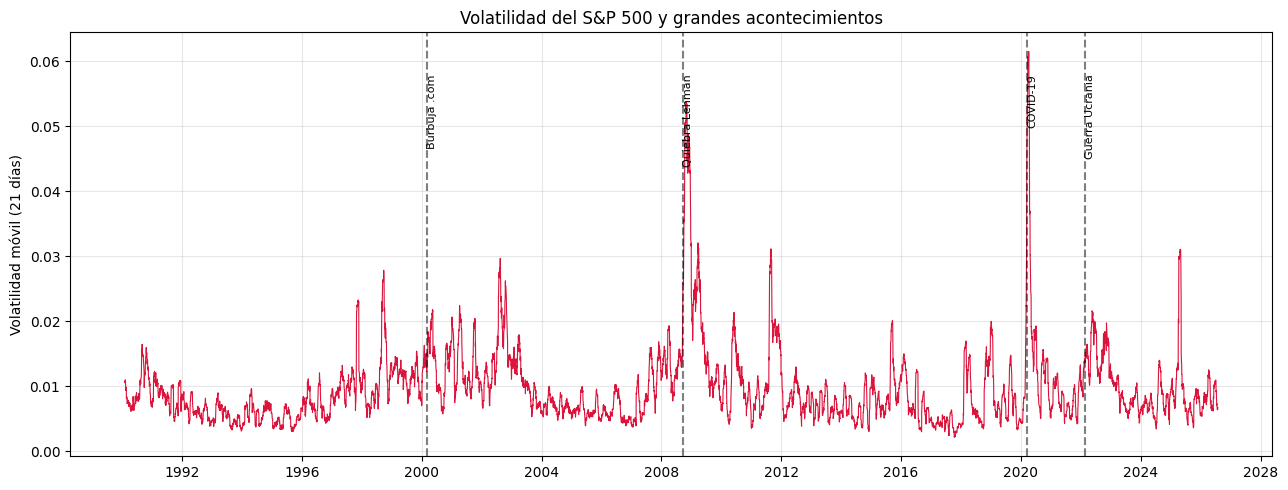

In [15]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sp500.index, sp500["vol_21d"], color="crimson", linewidth=0.8)
ax.set_title("Volatilidad del S&P 500 y grandes acontecimientos")
ax.set_ylabel("Volatilidad móvil (21 días)")
ax.grid(True, alpha=0.3)

# Marcamos algunos eventos históricos
eventos = {
    "2000-03-10": "Burbuja .com",
    "2008-09-15": "Quiebra Lehman",
    "2020-03-16": "COVID-19",
    "2022-02-24": "Guerra Ucrania",
}
for fecha, nombre in eventos.items():
    ax.axvline(pd.to_datetime(fecha), color="black", linestyle="--", alpha=0.5)
    ax.text(pd.to_datetime(fecha), ax.get_ylim()[1]*0.9, nombre,
            rotation=90, verticalalignment="top", fontsize=8)

plt.tight_layout()
plt.show()